Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.31      0.36        74
           1       0.65      0.75      0.70       126

    accuracy                           0.59       200
   macro avg       0.54      0.53      0.53       200
weighted avg       0.57      0.59      0.57       200



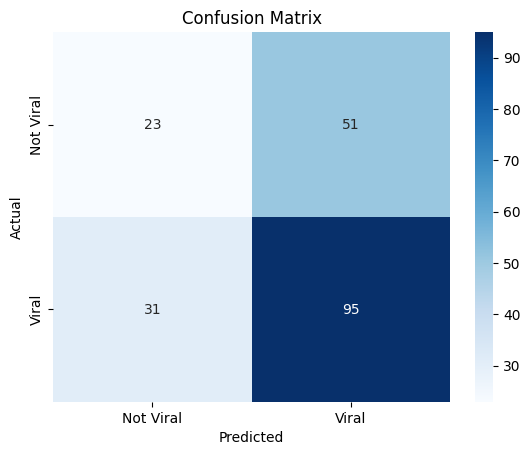

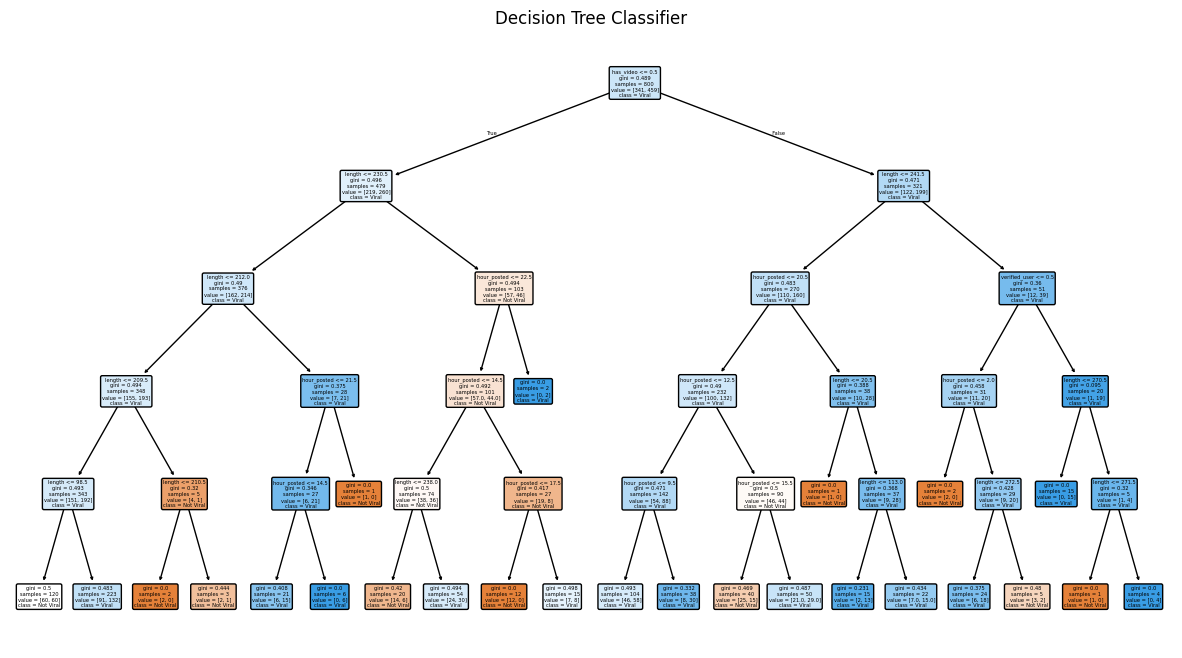


Misclassified Samples (First 5):
     length  hour_posted  verified_user  has_video  is_reply  true_label  \
521     216           18              1          0         0           0   
411     163           20              0          0         0           0   
626      66           19              0          1         0           0   
811      57            3              0          0         0           1   
636      27           11              1          1         0           0   

     predicted_label  
521                1  
411                1  
626                1  
811                0  
636                1  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns


np.random.seed(42)
n_samples = 1000
data = pd.DataFrame({
    "length": np.random.randint(20, 280, size=n_samples),
    "hour_posted": np.random.randint(0, 24, size=n_samples),
    "verified_user": np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3]),
    "has_video": np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4]),
    "is_reply": np.random.choice([0, 1], size=n_samples, p=[0.8, 0.2]),
})


data["retweet_count"] = (
    10 * data["verified_user"]
    + 8 * data["has_video"]
    + 5 * (data["hour_posted"].isin([9, 12, 18]).astype(int))
    + np.random.randint(0, 100, size=n_samples)
)
data["viral"] = (data["retweet_count"] > 50).astype(int)
data.drop(columns="retweet_count", inplace=True)


X = data.drop(columns="viral")
y = data["viral"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))


conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap="Blues", xticklabels=["Not Viral", "Viral"], yticklabels=["Not Viral", "Viral"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(15, 8))
plot_tree(clf, feature_names=X.columns, class_names=["Not Viral", "Viral"], filled=True, rounded=True)
plt.title("Decision Tree Classifier")
plt.show()


X_test["true_label"] = y_test
X_test["predicted_label"] = y_pred
misclassified = X_test[X_test["true_label"] != X_test["predicted_label"]]
print("\nMisclassified Samples (First 5):")
print(misclassified.head(5))
